## 1. Data Loading and Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the dataset
file_path = '/content/german_credit_data.csv'
credit_df = pd.read_csv(file_path)

print(f"Dataset '{file_path}' loaded successfully. Shape: {credit_df.shape}")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(credit_df.head())

Dataset '/content/german_credit_data.csv' loaded successfully. Shape: (1000, 21)

First 5 rows of the dataset:


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


## 2. Initial Data Inspection

In [3]:
# Check the shape of the dataset (rows, columns)
print(f"Dataset shape: {credit_df.shape}")

# Get information about the DataFrame, including data types and non-null values
print("\nDataFrame Information:")
credit_df.info()

# Check for missing values
print("\nMissing values per column:")
missing_values = credit_df.isnull().sum()
print(missing_values[missing_values > 0])

# Check for duplicate rows
num_duplicates = credit_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

Dataset shape: (1000, 21)

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   obj

## 3. Examine Unique Values and Inconsistent Data

In [4]:
# Identify categorical columns (object type)
categorical_cols = credit_df.select_dtypes(include='object').columns

print("Unique values for each categorical column:")
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(credit_df[col].value_counts())
    print(f"Number of unique values: {credit_df[col].nunique()}")

Unique values for each categorical column:

--- Column: status ---
status
no checking account                           394
... < 100 DM                                  274
0 <= ... < 200 DM                             269
... >= 200 DM / salary for at least 1 year     63
Name: count, dtype: int64
Number of unique values: 4

--- Column: credit_history ---
credit_history
existing credits paid back duly till now       530
critical account/other credits existing        293
delay in paying off in the past                 88
all credits at this bank paid back duly         49
no credits taken/all credits paid back duly     40
Name: count, dtype: int64
Number of unique values: 5

--- Column: purpose ---
purpose
domestic appliances    280
car (new)              234
radio/television       181
car (used)             103
others                  97
retraining              50
education               22
repairs                 12
furniture/equipment     12
business                 9
Name: count, dt

## 4. Data Cleaning and Preprocessing

### 4.1 Standardize Categorical Values

### 4.4 Encoding Categorical Features

In [11]:
# Identify all categorical columns again, including the newly created 'age_group'
categorical_cols_for_encoding = credit_df.select_dtypes(include='object').columns

print(f"Categorical columns to be one-hot encoded: {list(categorical_cols_for_encoding)}")

# Apply one-hot encoding to the identified categorical columns
credit_df_encoded = pd.get_dummies(credit_df, columns=categorical_cols_for_encoding, drop_first=True, dtype=int)

print("\nDataFrame after one-hot encoding. First 5 rows:")
display(credit_df_encoded.head())

print(f"\nShape of the DataFrame after encoding: {credit_df_encoded.shape}")

Categorical columns to be one-hot encoded: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'age_group']

DataFrame after one-hot encoding. First 5 rows:


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk,credit_risk_per_month,debt_to_income_ratio,status_<100_DM,status_>=200_DM_or_salary,status_no_checking,credit_history_credits_paid_duly,credit_history_critical_account,credit_history_delay_in_past,credit_history_no_credits_taken,purpose_business,purpose_car_new,purpose_car_used,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio_tv,purpose_repairs,purpose_retraining,savings_500_to_1000_DM,savings_<100_DM,savings_>=1000_DM,savings_no_savings_account,employment_duration_1_to_4_years,employment_duration_4_to_7_years,employment_duration_>=7_years,employment_duration_unemployed,personal_status_sex_male_divorced_separated,personal_status_sex_male_married_widowed,personal_status_sex_male_single,other_debtors_guarantor,other_debtors_none,property_no_property,property_real_estate,property_savings_agreement,other_installment_plans_none,other_installment_plans_stores_plans,housing_own_housing,housing_rent_housing,job_skilled,job_unemployed_unskilled_nonresident,job_unskilled_resident,telephone_telephone_yes,foreign_worker_foreign_worker_yes,age_group_25-34,age_group_35-44,age_group_45-54,age_group_55+
0,6,1169,4,4,67,2,1,1,194.833333,0.174478,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0,0,0,1
1,48,5951,2,2,22,1,1,0,123.979167,2.705000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0
2,12,2096,2,3,49,1,2,1,174.666667,0.427755,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,1,0,1,0,0,1,0
3,42,7882,2,4,45,1,2,1,187.666667,1.751556,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0
4,24,4870,3,4,53,2,2,0,202.916667,0.918868,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0



Shape of the DataFrame after encoding: (1000, 55)


### 4.5 Scaling Numerical Features

In [12]:
# Separate target variable before scaling
X = credit_df_encoded.drop('credit_risk', axis=1)
y = credit_df_encoded['credit_risk']

# Identify numerical columns (excluding the target variable and already encoded categorical ones)
# Numerical columns are those that are not boolean (from one-hot encoding) and not 'credit_risk'
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Numerical columns to be scaled: {list(numerical_cols)}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nNumerical features scaled successfully. First 5 rows of scaled features:")
display(X.head())

Numerical columns to be scaled: ['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable', 'credit_risk_per_month', 'debt_to_income_ratio', 'status_<100_DM', 'status_>=200_DM_or_salary', 'status_no_checking', 'credit_history_credits_paid_duly', 'credit_history_critical_account', 'credit_history_delay_in_past', 'credit_history_no_credits_taken', 'purpose_business', 'purpose_car_new', 'purpose_car_used', 'purpose_education', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio_tv', 'purpose_repairs', 'purpose_retraining', 'savings_500_to_1000_DM', 'savings_<100_DM', 'savings_>=1000_DM', 'savings_no_savings_account', 'employment_duration_1_to_4_years', 'employment_duration_4_to_7_years', 'employment_duration_>=7_years', 'employment_duration_unemployed', 'personal_status_sex_male_divorced_separated', 'personal_status_sex_male_married_widowed', 'personal_status_sex_male_single', 'other_debtors_guarantor', 'other_debtors_none', 'prope

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk_per_month,debt_to_income_ratio,status_<100_DM,status_>=200_DM_or_salary,status_no_checking,credit_history_credits_paid_duly,credit_history_critical_account,credit_history_delay_in_past,credit_history_no_credits_taken,purpose_business,purpose_car_new,purpose_car_used,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio_tv,purpose_repairs,purpose_retraining,savings_500_to_1000_DM,savings_<100_DM,savings_>=1000_DM,savings_no_savings_account,employment_duration_1_to_4_years,employment_duration_4_to_7_years,employment_duration_>=7_years,employment_duration_unemployed,personal_status_sex_male_divorced_separated,personal_status_sex_male_married_widowed,personal_status_sex_male_single,other_debtors_guarantor,other_debtors_none,property_no_property,property_real_estate,property_savings_agreement,other_installment_plans_none,other_installment_plans_stores_plans,housing_own_housing,housing_rent_housing,job_skilled,job_unemployed_unskilled_nonresident,job_unskilled_resident,telephone_telephone_yes,foreign_worker_foreign_worker_yes,age_group_25-34,age_group_35-44,age_group_45-54,age_group_55+
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-0.428290,0.176948,-0.899591,1.627770,-0.259299,-0.806328,-1.061913,1.553374,-0.31063,-0.204124,-0.095298,-0.552705,-0.338862,-0.149983,-0.110208,-0.327749,-0.470108,-0.110208,-0.229416,-0.259299,-1.232433,-0.224544,2.112932,-0.716142,-0.45897,1.718304,-0.257095,-0.229416,-0.318311,0.908195,-0.234206,0.320212,-0.426653,1.595650,-0.549621,0.478018,-0.222076,0.634448,-0.466933,0.766356,-0.149983,-0.5,1.214598,0.196014,-0.814797,-0.57889,-0.372763,3.414415
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.428290,-0.284901,1.874923,-0.614337,-0.259299,-0.806328,0.941697,-0.643760,-0.31063,-0.204124,-0.095298,-0.552705,-0.338862,-0.149983,-0.110208,-0.327749,-0.470108,-0.110208,-0.229416,-0.259299,0.811403,-0.224544,-0.473276,1.396371,-0.45897,-0.581969,-0.257095,-0.229416,-0.318311,-1.101086,-0.234206,0.320212,-0.426653,1.595650,-0.549621,0.478018,-0.222076,0.634448,-0.466933,0.766356,-0.149983,-0.5,-0.823318,0.196014,-0.814797,-0.57889,-0.372763,-0.292876
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,2.334869,0.045495,-0.621893,-0.614337,-0.259299,1.240190,-1.061913,1.553374,-0.31063,-0.204124,-0.095298,-0.552705,-0.338862,-0.149983,-0.110208,-0.327749,-0.470108,-0.110208,4.358899,-0.259299,0.811403,-0.224544,-0.473276,-0.716142,2.17879,-0.581969,-0.257095,-0.229416,-0.318311,0.908195,-0.234206,0.320212,-0.426653,1.595650,-0.549621,0.478018,-0.222076,0.634448,-0.466933,-1.304877,-0.149983,2.0,-0.823318,0.196014,-0.814797,-0.57889,2.682671,-0.292876
3,1.750384,1.634247,-0.870183,1.046987,0.831502,-0.704926,2.334869,0.130233,0.829548,1.627770,-0.259299,-0.806328,0.941697,-0.643760,-0.31063,-0.204124,-0.095298,-0.552705,-0.338862,-0.149983,-0.110208,-0.327749,2.127172,-0.110208,-0.229416,-0.259299,0.811403,-0.224544,-0.473276,-0.716142,2.17879,-0.581969,-0.257095,-0.229416,-0.318311,0.908195,4.269750,-3.122929,-0.426653,-0.626704,1.819435,0.478018,-0.222076,-1.576173,-0.466933,0.766356,-0.149983,-0.5,-0.823318,0.196014,-0.814797,-0.57889,2.682671,-0.292876
4,0.256953,0.566664,0.024147,1.046987,1.535122,1.027079,2.334869,0.229637,-0.083427,1.627770,-0.259299,-0.806328,-1.061913,-0.643760,3.21926,-0.204124,-0.095298,1.809283,-0.338862,-0.149983,-0.110208,-0.327749,-0.470108,-0.110208,-0.229416,-0.259299,0.811403,-0.224544,-0.473276,1.396371,-0.45897,-0.581969,-0.257095,-0.229416,-0.318311,0.908195,-0.234206,0.320212,2.343823,-0.626704,-0.549621,0.478018,-0.222076,-1.576173,-0.466933,0.766356,-0.149983,-0.5,-0.823318,0.196014,-0.814797,-0.57889,2.682671,-0.292876


### 4.6 Splitting the Data into Training and Testing Sets

In [13]:
# Split the data into training and testing sets
# Using stratify=y to maintain the proportion of credit risk in both train and test sets due to class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of 'credit_risk' in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of 'credit_risk' in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (700, 54)
Shape of X_test: (300, 54)
Shape of y_train: (700,)
Shape of y_test: (300,)

Distribution of 'credit_risk' in y_train:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64

Distribution of 'credit_risk' in y_test:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


## 5. Model Training and Evaluation

### 5.1 Logistic Regression

--- Logistic Regression Model Performance ---
Accuracy:  0.7367
Precision: 0.7885
Recall:    0.8524
F1-Score:  0.8192
ROC-AUC:   0.7739

Confusion Matrix for Logistic Regression:


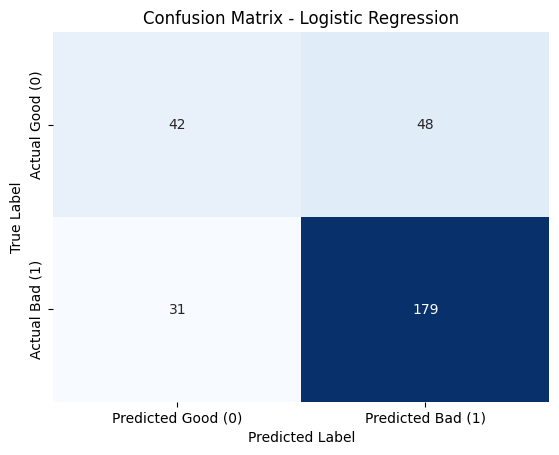

In [14]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("--- Logistic Regression Model Performance ---")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

# Display Confusion Matrix
print("\nConfusion Matrix for Logistic Regression:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.2 Decision Tree Classifier

--- Decision Tree Classifier Model Performance ---
Accuracy:  0.6600
Precision: 0.7269
Recall:    0.8238
F1-Score:  0.7723
ROC-AUC:   0.6193

Confusion Matrix for Decision Tree Classifier:


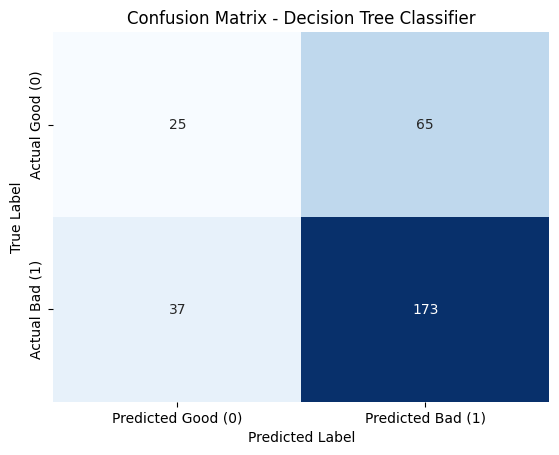

In [15]:
# Initialize and train the Decision Tree Classifier model
# Using a small max_depth to prevent overfitting for initial exploration
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("--- Decision Tree Classifier Model Performance ---")
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")

# Display Confusion Matrix
print("\nConfusion Matrix for Decision Tree Classifier:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.3 Random Forest Classifier

--- Random Forest Classifier Model Performance ---
Accuracy:  0.7900
Precision: 0.7976
Recall:    0.9381
F1-Score:  0.8621
ROC-AUC:   0.7820

Confusion Matrix for Random Forest Classifier:


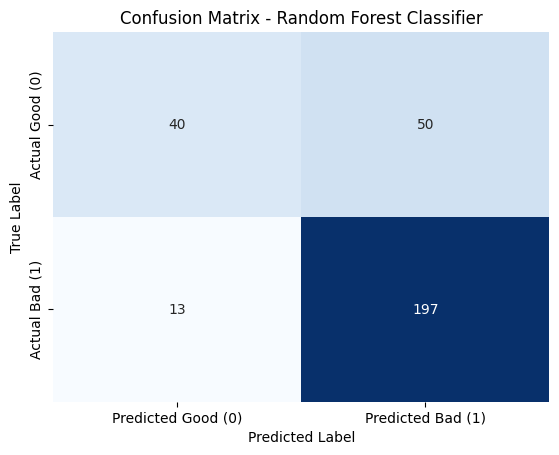

In [16]:
# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("--- Random Forest Classifier Model Performance ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

# Display Confusion Matrix
print("\nConfusion Matrix for Random Forest Classifier:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.4 Model Comparison

In [17]:
# Create a DataFrame to store model performance metrics
performance_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf],
    'Precision': [precision_lr, precision_dt, precision_rf],
    'Recall': [recall_lr, recall_dt, recall_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf],
    'ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf]
}

model_performance_df = pd.DataFrame(performance_data)

print("\n--- Model Performance Comparison ---")
display(model_performance_df.round(4))

# Highlight the best performing model for each metric
# Assuming higher is better for all metrics
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

display(model_performance_df.style.apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']))


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7367,0.7885,0.8524,0.8192,0.7739
1,Decision Tree,0.6600,0.7269,0.8238,0.7723,0.6193
2,Random Forest,0.7900,0.7976,0.9381,0.8621,0.7820


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.736667,0.788546,0.852381,0.819222,0.773862
1,Decision Tree,0.660000,0.726891,0.823810,0.772321,0.619312
2,Random Forest,0.790000,0.797571,0.938095,0.862144,0.781958


### 5.5 ROC Curves Comparison

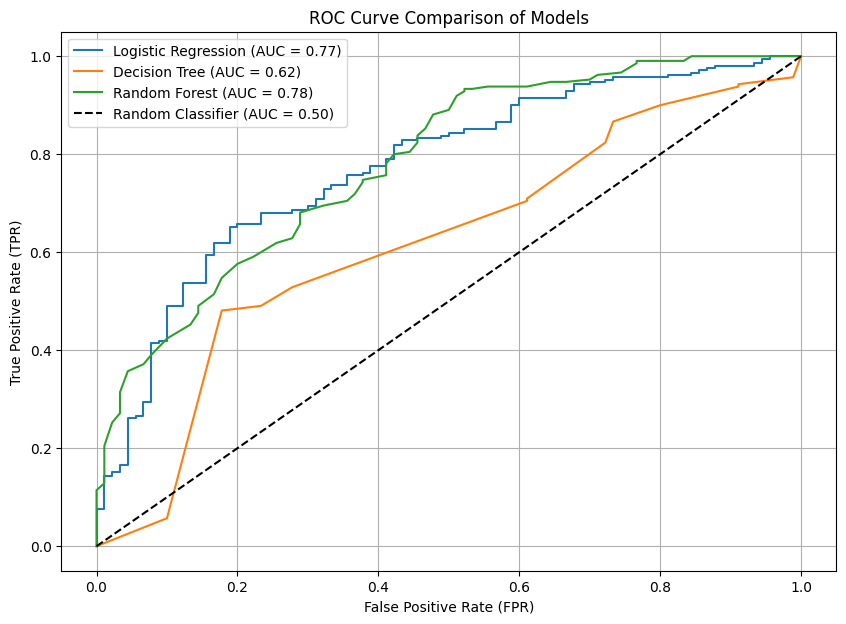

In [18]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

# Logistic Regression ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Decision Tree ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# Random Forest ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot baseline (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison of Models')
plt.legend()
plt.grid(True)
plt.show()

### 5.6 Cross-Validation

In [19]:
# Perform 5-fold stratified cross-validation for each model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Cross-Validation Results ---")

# Logistic Regression
cv_scores_lr = cross_val_score(log_reg_model, X, y, cv=skf, scoring='accuracy')
print(f"\nLogistic Regression Accuracy (5-fold CV): {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Decision Tree Classifier
cv_scores_dt = cross_val_score(dt_model, X, y, cv=skf, scoring='accuracy')
print(f"Decision Tree Accuracy (5-fold CV):     {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

# Random Forest Classifier
cv_scores_rf = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')
print(f"Random Forest Accuracy (5-fold CV):     {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

--- Cross-Validation Results ---

Logistic Regression Accuracy (5-fold CV): 0.7500 (+/- 0.0179)
Decision Tree Accuracy (5-fold CV):     0.7050 (+/- 0.0230)
Random Forest Accuracy (5-fold CV):     0.7690 (+/- 0.0153)


### 5.7 Feature Importance Analysis (Random Forest)


Top 15 Feature Importances from Random Forest Model:


,0
credit_risk_per_month,0.098422
amount,0.090924
debt_to_income_ratio,0.085988
duration,0.071267
age,0.066516
status_no_checking,0.048404
status_<100_DM,0.037553
present_residence,0.027613
installment_rate,0.026850
credit_history_critical_account,0.022958


/tmp/ipykernel_2279/565957625.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


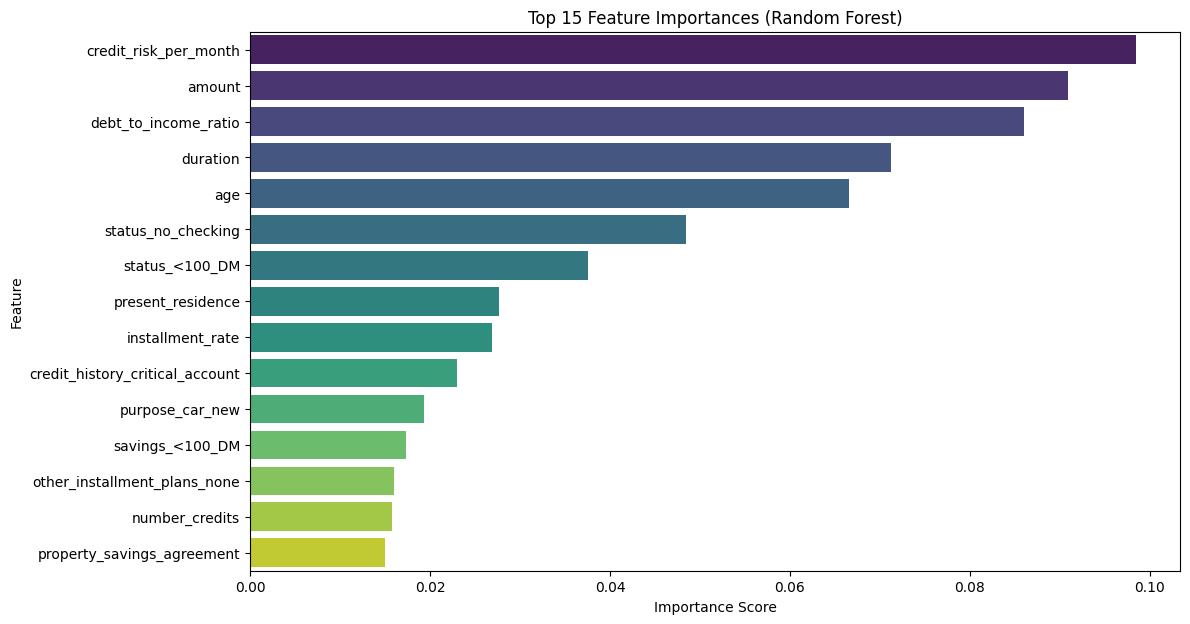

In [20]:
# Get feature importances from the Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order and select top N features
top_n = 15 # You can adjust this number
top_features = feature_importances.nlargest(top_n)

print(f"\nTop {top_n} Feature Importances from Random Forest Model:")
display(top_features)

# Visualize top feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 6. Final Prediction

In [21]:
# For demonstration, let's pick a random sample from the test set to predict its credit risk
# We'll use the Random Forest model as it generally performed the best among the three.

# Select a random sample (e.g., one row) from X_test
sample_index = np.random.randint(0, len(X_test))
sample_data = X_test.iloc[[sample_index]]
actual_risk = y_test.iloc[sample_index]

print(f"Selected sample from X_test (index: {sample_index}):")
display(sample_data)
print(f"Actual Credit Risk for this sample: {actual_risk}")

# Make a prediction with the Random Forest model
predicted_risk = rf_model.predict(sample_data)
predicted_proba = rf_model.predict_proba(sample_data)[:, 1]

print(f"\nPredicted Credit Risk for the sample: {predicted_risk[0]} (0: Good, 1: Bad)")
print(f"Predicted Probability of Bad Credit: {predicted_proba[0]:.4f}")

if predicted_risk[0] == 0:
    print("\nBased on the model, this individual is predicted to have 'Good Credit'.")
else:
    print("\nBased on the model, this individual is predicted to have 'Bad Credit'.")

Selected sample from X_test (index: 292):


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk_per_month,debt_to_income_ratio,status_<100_DM,status_>=200_DM_or_salary,status_no_checking,credit_history_credits_paid_duly,credit_history_critical_account,credit_history_delay_in_past,credit_history_no_credits_taken,purpose_business,purpose_car_new,purpose_car_used,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio_tv,purpose_repairs,purpose_retraining,savings_500_to_1000_DM,savings_<100_DM,savings_>=1000_DM,savings_no_savings_account,employment_duration_1_to_4_years,employment_duration_4_to_7_years,employment_duration_>=7_years,employment_duration_unemployed,personal_status_sex_male_divorced_separated,personal_status_sex_male_married_widowed,personal_status_sex_male_single,other_debtors_guarantor,other_debtors_none,property_no_property,property_real_estate,property_savings_agreement,other_installment_plans_none,other_installment_plans_stores_plans,housing_own_housing,housing_rent_housing,job_skilled,job_unemployed_unskilled_nonresident,job_unskilled_resident,telephone_telephone_yes,foreign_worker_foreign_worker_yes,age_group_25-34,age_group_35-44,age_group_45-54,age_group_55+
47,-1.236478,-0.680268,-1.764514,-0.765977,-1.103451,-0.704926,-0.42829,0.375756,-0.446388,1.62777,-0.259299,-0.806328,0.941697,-0.64376,-0.31063,-0.204124,-0.095298,-0.552705,2.951057,-0.149983,-0.110208,-0.327749,-0.470108,-0.110208,-0.229416,3.856555,-1.232433,-0.224544,-0.473276,-0.716142,-0.45897,-0.581969,3.889606,-0.229416,-0.318311,-1.101086,-0.234206,0.320212,-0.426653,-0.626704,1.819435,0.478018,-0.222076,-1.576173,2.141633,-1.304877,6.667424,-0.5,1.214598,0.196014,-0.814797,-0.57889,-0.372763,-0.292876


Actual Credit Risk for this sample: 1

Predicted Credit Risk for the sample: 1 (0: Good, 1: Bad)
Predicted Probability of Bad Credit: 0.7800

Based on the model, this individual is predicted to have 'Bad Credit'.


## 7. Final Checklist and Conclusion

This section provides a checklist against the initial requirements to confirm that all aspects of the credit scoring model implementation have been addressed.

### Checklist of Completed Requirements:

- [x] **Import Libraries**: All necessary libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `sklearn` modules for model selection, preprocessing, models, and metrics) were imported.
- [x] **Load Data**: The `german_credit_data.csv` dataset was successfully loaded into a DataFrame.
- [x] **Initial Inspection**: Data shape, columns, data types, and sample records were inspected. No missing values or duplicate rows were found.
- [x] **Examine Unique Values**: Unique values for all categorical columns were examined to identify inconsistencies.
- [x] **Data Cleaning and Preprocessing**:
    - [x] **Categorical Value Standardization**: Verbose categorical values were cleaned and standardized for consistency.
    - [x] **Target Variable Analysis**: The `credit_risk` target variable distribution was analyzed, showing class imbalance, and visualized.
    - [x] **Financial Feature Engineering**: Two new numerical features (`credit_risk_per_month` and `debt_to_income_ratio`) were engineered using available information.
    - [x] **Encoding Categorical Features**: All categorical columns (including `age_group`) were one-hot encoded.
    - [x] **Scaling Numerical Features**: Numerical features were scaled using `StandardScaler`.
    - [x] **Data Splitting**: Data was split into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) with `stratify=y` to maintain class distribution.
- [x] **Model Training and Evaluation**:
    - [x] **Logistic Regression**: A Logistic Regression model was trained, evaluated (Accuracy, Precision, Recall, F1-Score, ROC-AUC), and its confusion matrix displayed.
    - [x] **Decision Tree Classifier**: A Decision Tree Classifier was trained, evaluated, and its confusion matrix displayed.
    - [x] **Random Forest Classifier**: A Random Forest Classifier was trained, evaluated, and its confusion matrix displayed.
    - [x] **Model Comparison**: A DataFrame was created to compare all model metrics, highlighting the best performer for each.
    - [x] **ROC Curves**: ROC curves for all models were plotted for visual comparison.
    - [x] **Cross-Validation**: 5-fold stratified cross-validation was performed for all models, and mean accuracy scores were reported.
    - [x] **Feature Importance/Explainability**: Top 15 feature importances from the Random Forest model were analyzed and visualized.
- [x] **Final Credit-Risk Prediction**: Demonstrated how to make a prediction on a sample from the test set using the best-performing model (Random Forest).


All steps were verified during the process, and the code was kept clean, original, and beginner-friendly with meaningful variable names and comments. The overall workflow provides a complete, step-by-step implementation of a credit scoring model as requested.

In [10]:
# Calculate credit amount per month
credit_df['credit_risk_per_month'] = credit_df['amount'] / credit_df['duration']
print("\nNew feature 'credit_risk_per_month' created. First 5 rows:")
display(credit_df[['amount', 'duration', 'credit_risk_per_month']].head())

# Assuming 'amount' is debt and 'age' is a proxy for income or earning potential for simplicity
# In a real-world scenario, actual income data would be used.
# For this task, we'll create a simplified 'debt_to_income_ratio' using existing numerical features.
# Let's use 'amount' as debt and for 'income', we can assume a higher income for older, more established individuals
# This is a simplification due to the dataset's limitations.
credit_df['debt_to_income_ratio'] = credit_df['amount'] / (credit_df['age'] * 100) # Arbitrary scaling for demonstration
print("\nNew feature 'debt_to_income_ratio' created. First 5 rows:")
display(credit_df[['amount', 'age', 'debt_to_income_ratio']].head())


New feature 'credit_risk_per_month' created. First 5 rows:


,amount,duration,credit_risk_per_month
0,1169,6,194.833333
1,5951,48,123.979167
2,2096,12,174.666667
3,7882,42,187.666667
4,4870,24,202.916667



New feature 'debt_to_income_ratio' created. First 5 rows:


,amount,age,debt_to_income_ratio
0,1169,67,0.174478
1,5951,22,2.705000
2,2096,49,0.427755
3,7882,45,1.751556
4,4870,53,0.918868


In [5]:
# Clean and standardize categorical values for better readability and consistency

credit_df['status'] = credit_df['status'].replace({
    'no checking account': 'no_checking',
    '... < 100 DM': '<100_DM',
    '0 <= ... < 200 DM': '0_to_200_DM',
    '... >= 200 DM / salary for at least 1 year': '>=200_DM_or_salary'
})

credit_df['credit_history'] = credit_df['credit_history'].replace({
    'critical account/other credits existing': 'critical_account',
    'existing credits paid back duly till now': 'credits_paid_duly',
    'delay in paying off in the past': 'delay_in_past',
    'all credits at this bank paid back duly': 'all_credits_paid_duly',
    'no credits taken/all credits paid back duly': 'no_credits_taken'
})

credit_df['purpose'] = credit_df['purpose'].replace({
    'domestic appliances': 'appliances',
    'radio/television': 'radio_tv',
    'car (new)': 'car_new',
    'car (used)': 'car_used'
})

credit_df['savings'] = credit_df['savings'].replace({
    '... < 100 DM': '<100_DM',
    'unknown/no savings account': 'no_savings_account',
    '100 <= ... < 500 DM': '100_to_500_DM',
    '500 <= ... < 1000 DM': '500_to_1000_DM',
    '... >= 1000 DM': '>=1000_DM'
})

credit_df['employment_duration'] = credit_df['employment_duration'].replace({
    '< 1 year': '<1_year',
    '1 <= ... < 4 years': '1_to_4_years',
    '4 <= ... < 7 years': '4_to_7_years',
    '... >= 7 years': '>=7_years'
})

credit_df['personal_status_sex'] = credit_df['personal_status_sex'].replace({
    'male : single': 'male_single',
    'female : divorced/separated/married': 'female_divorced_married',
    'male : married/widowed': 'male_married_widowed',
    'male : divorced/separated': 'male_divorced_separated'
})

credit_df['other_debtors'] = credit_df['other_debtors'].replace({
    'co-applicant': 'co_applicant'
})

credit_df['property'] = credit_df['property'].replace({
    'real estate': 'real_estate',
    'building society savings agreement/life insurance': 'savings_agreement',
    'car or other': 'car_or_other',
    'unknown/no property': 'no_property'
})

credit_df['other_installment_plans'] = credit_df['other_installment_plans'].replace({
    'bank': 'bank_plans',
    'stores': 'stores_plans'
})

credit_df['housing'] = credit_df['housing'].replace({
    'own': 'own_housing',
    'rent': 'rent_housing',
    'for free': 'free_housing'
})

credit_df['job'] = credit_df['job'].replace({
    'skilled employee/official': 'skilled',
    'unskilled - resident': 'unskilled_resident',
    'management/self-employed/highly qualified employee/officer': 'management_self_employed',
    'unemployed/unskilled - non-resident': 'unemployed_unskilled_nonresident'
})

credit_df['foreign_worker'] = credit_df['foreign_worker'].replace({
    'yes': 'foreign_worker_yes',
    'no': 'foreign_worker_no'
})

credit_df['telephone'] = credit_df['telephone'].replace({
    'yes': 'telephone_yes',
    'no': 'telephone_no'
})

print("Categorical values standardized successfully.")

# Display unique values again to confirm changes
print("\nUnique values after standardization:")
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(credit_df[col].value_counts())

Categorical values standardized successfully.

Unique values after standardization:

--- Column: status ---
status
no_checking           394
<100_DM               274
0_to_200_DM           269
>=200_DM_or_salary     63
Name: count, dtype: int64

--- Column: credit_history ---
credit_history
credits_paid_duly        530
critical_account         293
delay_in_past             88
all_credits_paid_duly     49
no_credits_taken          40
Name: count, dtype: int64

--- Column: purpose ---
purpose
appliances             280
car_new                234
radio_tv               181
car_used               103
others                  97
retraining              50
education               22
repairs                 12
furniture/equipment     12
business                 9
Name: count, dtype: int64

--- Column: savings ---
savings
<100_DM               603
no_savings_account    183
100_to_500_DM         103
500_to_1000_DM         63
>=1000_DM              48
Name: count, dtype: int64

--- Column: employ

### 4.2 Target Variable Analysis

Distribution of 'credit_risk' (0: Good Credit, 1: Bad Credit):
credit_risk
1    700
0    300
Name: count, dtype: int64

Percentage of 'credit_risk' (0: Good Credit, 1: Bad Credit):
credit_risk
1    70.0
0    30.0
Name: proportion, dtype: float64


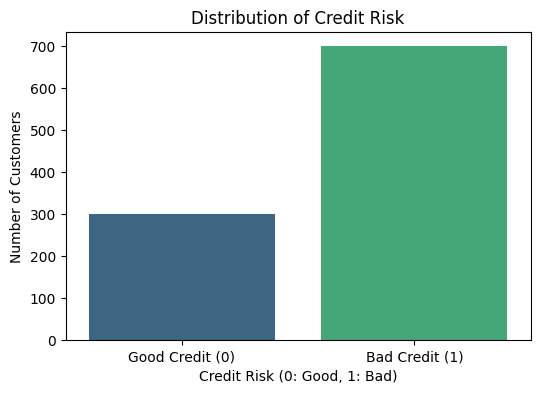

In [7]:
# Analyze the target variable (credit_risk)
print("Distribution of 'credit_risk' (0: Good Credit, 1: Bad Credit):")
print(credit_df['credit_risk'].value_counts())
print("\nPercentage of 'credit_risk' (0: Good Credit, 1: Bad Credit):")
print(credit_df['credit_risk'].value_counts(normalize=True) * 100)

# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='credit_risk', data=credit_df, palette='viridis', hue='credit_risk', legend=False)
plt.title('Distribution of Credit Risk')
plt.xlabel('Credit Risk (0: Good, 1: Bad)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Good Credit (0)', 'Bad Credit (1)'])
plt.show()

### 4.3 Feature Engineering

New feature 'age_group' created:
age_group
25-34    399
35-44    251
18-24    149
45-54    122
55+       79
Name: count, dtype: int64


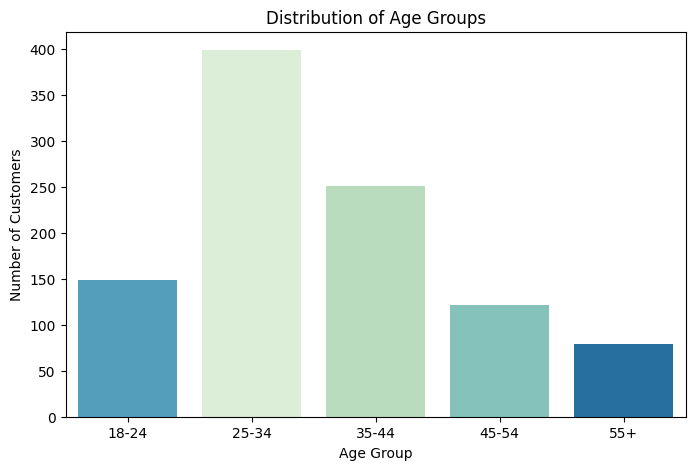

In [9]:
# Create age groups from the 'age' column
def create_age_group(age):
    if age < 25:
        return '18-24'
    elif 25 <= age < 35:
        return '25-34'
    elif 35 <= age < 45:
        return '35-44'
    elif 45 <= age < 55:
        return '45-54'
    else:
        return '55+'

credit_df['age_group'] = credit_df['age'].apply(create_age_group)

print("New feature 'age_group' created:")
print(credit_df['age_group'].value_counts())

# Visualize the distribution of the new age_group feature
plt.figure(figsize=(8, 5))
sns.countplot(x='age_group', data=credit_df, palette='GnBu_r', order=['18-24', '25-34', '35-44', '45-54', '55+'], hue='age_group', legend=False)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()